# Phase 5: Evaluation and Error Analysis

Evaluates the 4 models saved in Phase 4 on `data/test_features.csv` (touched for the first time here — everything before this notebook was tuned/selected using only `data/train.csv` / cross-validation on it).

**Convention used throughout this notebook**: precision/recall/F1 treat **phishing (`label=0`) as the positive class**, not scikit-learn's default `label=1`. Operationally, "recall" needs to mean "of all actual phishing URLs, how many did we catch" — the opposite framing would silently measure something else.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so `src.*` imports resolve when running from notebooks/

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score, roc_curve,
)

from src.features.extract import FEATURE_NAMES

COLOR_LEGIT = "#2a78d6"
COLOR_PHISH = "#eb6834"
FIG_DIR = "../reports/figures"

test_features = pd.read_csv("../data/test_features.csv")
test_urls = pd.read_csv("../data/test.csv")
assert len(test_features) == len(test_urls), "row order must match: both built from the same split"

X_test = test_features[FEATURE_NAMES]
y_test = test_features["label"]
y_phish = (y_test == 0).astype(int)  # 1 = actually phishing

MODEL_PATHS = {
    "Logistic Regression": "../models_saved/logistic_regression_v1.joblib",
    "Random Forest": "../models_saved/random_forest_v1.joblib",
    "XGBoost": "../models_saved/xgboost_v1.joblib",
    "XGBoost (tuned)": "../models_saved/xgboost_tuned_v1.joblib",
}
models = {name: joblib.load(path) for name, path in MODEL_PATHS.items()}


def phish_proba(model, X):
    return 1 - model.predict_proba(X)[:, 1]


print(f"X_test {X_test.shape}, positive (phishing) rate {y_phish.mean():.4f}")


X_test (47074, 17), positive (phishing) rate 0.4271


## 1. Metrics and confusion matrices, all 4 models (default 0.5 threshold)

                     precision  recall      f1  roc_auc
model                                                  
Logistic Regression     0.9991  0.9881  0.9936   0.9982
Random Forest           0.9991  0.9941  0.9966   0.9982
XGBoost                 0.9997  0.9941  0.9969   0.9986
XGBoost (tuned)         0.9996  0.9937  0.9967   0.9986


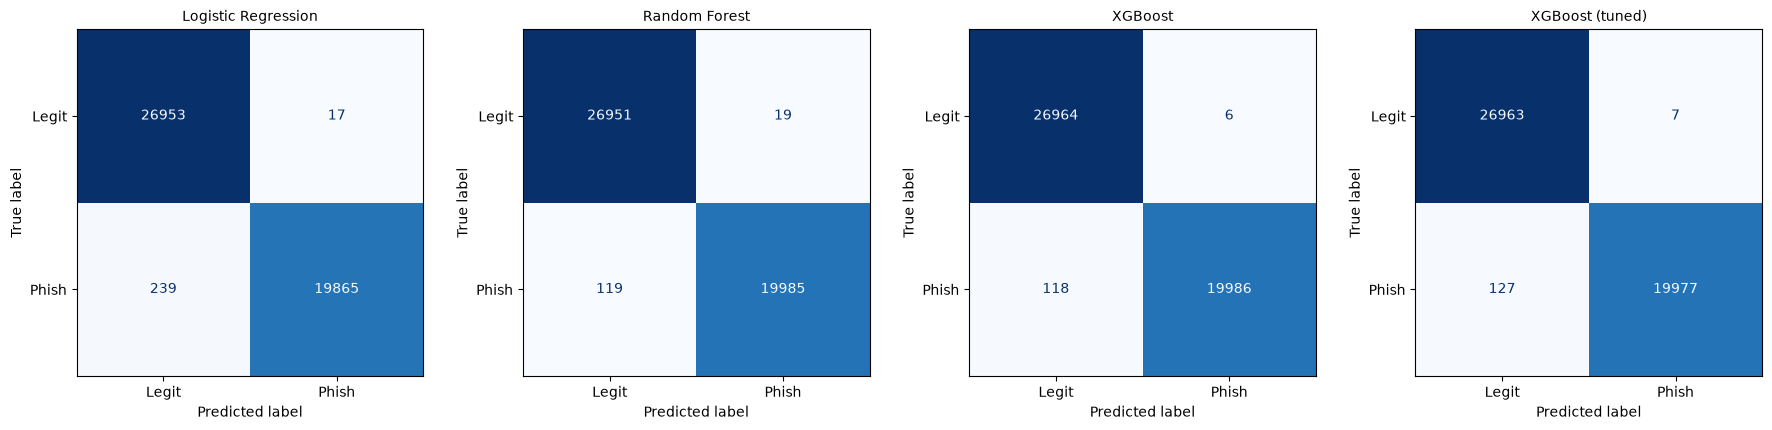

In [2]:
rows = []
proba_by_model = {}
for name, model in models.items():
    proba = phish_proba(model, X_test)
    proba_by_model[name] = proba
    pred = (proba >= 0.5).astype(int)
    rows.append({
        "model": name,
        "precision": round(precision_score(y_phish, pred), 4),
        "recall": round(recall_score(y_phish, pred), 4),
        "f1": round(f1_score(y_phish, pred), 4),
        "roc_auc": round(roc_auc_score(y_phish, proba), 4),
    })
metrics_df = pd.DataFrame(rows).set_index("model")
print(metrics_df)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, (name, model) in zip(axes, models.items()):
    pred = (proba_by_model[name] >= 0.5).astype(int)
    cm = confusion_matrix(y_phish, pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Phish"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_confusion_matrices.png", dpi=150)
plt.show()


## 2. ROC curves, all 4 models

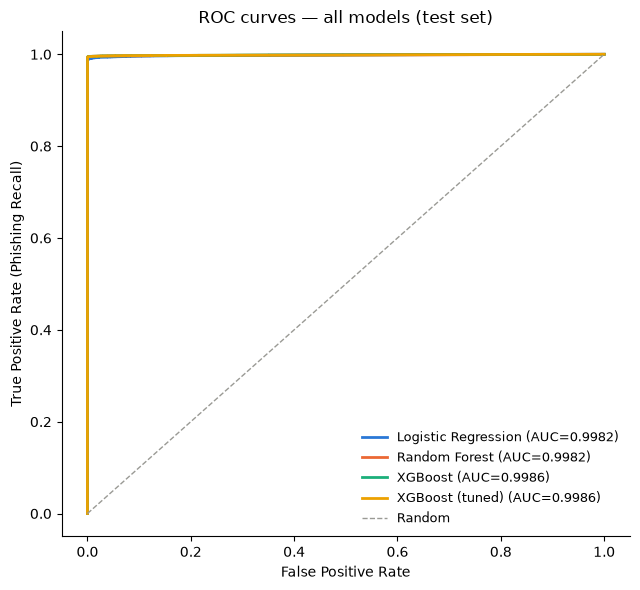

In [3]:
# Fixed-order categorical palette (4 series; validated colorblind-safe order per dataviz skill).
SERIES_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]

fig, ax = plt.subplots(figsize=(6.5, 6))
for color, (name, model) in zip(SERIES_COLORS, models.items()):
    fpr, tpr, _ = roc_curve(y_phish, proba_by_model[name])
    auc = metrics_df.loc[name, "roc_auc"]
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc:.4f})")
ax.plot([0, 1], [0, 1], color="#9a9a95", linestyle="--", linewidth=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Phishing Recall)")
ax.set_title("ROC curves — all models (test set)")
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_roc_curves.png", dpi=150)
plt.show()


## 3. Precision/recall tradeoff and threshold tuning

**Reasoning, specific to phishing URL detection:** a **false negative** here means a phishing URL is classified as legitimate — the user is not warned, and if this is deployed as a filter/browser-warning system, the attack goes through unimpeded. A **false positive** means a legitimate URL gets flagged — the cost is user friction (a warning the user has to click past, or a support ticket if it blocks something like a company's own SSO login). These costs are not symmetric: a missed phishing URL can lead to credential theft, financial fraud, or malware installation, while a false alarm costs a few seconds of annoyance. **This argues for prioritizing recall over precision for this specific use case** — not blindly, but because the downside of the false-negative failure mode (real financial/security harm) is categorically worse than the downside of the false-positive failure mode (friction) for a URL-filtering product. F1 (which weights them equally) is still reported as a balance check, but the threshold decision below is deliberately recall-weighted.

**Threshold selection method (leakage-safe):** the threshold is chosen using **out-of-fold cross-validated probabilities on `data/train.csv` only** (5-fold `cross_val_predict`), never by peeking at test-set performance at different thresholds — tuning a threshold against the test set would be the same over-tuning-on-the-test-set mistake as re-tuning hyperparameters against it. The chosen threshold is then applied to the test set exactly once, for reporting only.

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve
from xgboost import XGBClassifier

train_features = pd.read_csv("../data/train_features.csv")
X_train, y_train = train_features[FEATURE_NAMES], train_features["label"]
y_train_phish = (y_train == 0).astype(int)

# XGBoost (untuned) is the threshold-tuning candidate: see the Model
# Comparison section's finding that it edges out the tuned variant on
# phishing-recall at the deployed threshold, despite the tuned version's
# higher CV ROC-AUC (ROC-AUC is threshold-independent and doesn't guarantee
# the winner at any one operating point).
xgb_candidate = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric="logloss", n_jobs=-1, random_state=42,
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba_legit = cross_val_predict(xgb_candidate, X_train, y_train, cv=skf, method="predict_proba", n_jobs=-1)[:, 1]
oof_proba_phish = 1 - oof_proba_legit

precisions, recalls, thresholds = precision_recall_curve(y_train_phish, oof_proba_phish)
f2 = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-12)
best_idx = int(np.nanargmax(f2[:-1]))
print(f"F2-optimal (train, OOF): threshold={thresholds[best_idx]:.3f}, "
      f"precision={precisions[best_idx]:.4f}, recall={recalls[best_idx]:.4f}, F2={f2[best_idx]:.4f}")

# Also show what it costs to push recall to ~0.999: illustrates why we don't.
mask = recalls[:-1] >= 0.999
if mask.any():
    idx999 = np.argmax(precisions[:-1][mask])
    print(f"Recall>=0.999 (train, OOF) costs precision down to "
          f"{precisions[:-1][mask][idx999]:.4f} at threshold={thresholds[mask][idx999]:.4f} - too much "
          f"false-alarm volume for production use; not adopted.")

CHOSEN_THRESHOLD = 0.25  # close to the F2-optimum above, rounded for a clean operating point
print(f"\nChosen operating threshold: {CHOSEN_THRESHOLD}")


F2-optimal (train, OOF): threshold=0.248, precision=0.9984, recall=0.9947, F2=0.9954
Recall>=0.999 (train, OOF) costs precision down to 0.5334 at threshold=0.0011 - too much false-alarm volume for production use; not adopted.

Chosen operating threshold: 0.25


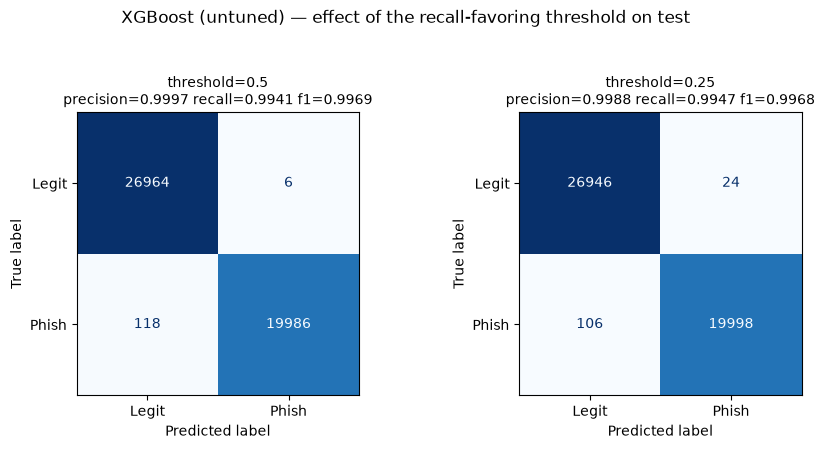

In [5]:
final_candidate_proba = proba_by_model["XGBoost"]  # untuned XGBoost, fit on full train

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, thr in zip(axes, [0.5, CHOSEN_THRESHOLD]):
    pred = (final_candidate_proba >= thr).astype(int)
    cm = confusion_matrix(y_phish, pred, labels=[0, 1])
    p, r, f = precision_score(y_phish, pred), recall_score(y_phish, pred), f1_score(y_phish, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Phish"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(f"threshold={thr}\nprecision={p:.4f} recall={r:.4f} f1={f:.4f}", fontsize=10)
plt.suptitle("XGBoost (untuned) — effect of the recall-favoring threshold on test", y=1.05)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_threshold_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Error analysis (XGBoost, threshold=0.25)

Pulling every misclassified test example and looking for patterns, rather than stopping at the metrics table.

In [6]:
pred_final = (final_candidate_proba >= CHOSEN_THRESHOLD).astype(int)

err = test_urls.copy()
err["y_phish"] = y_phish.values
err["pred_phish"] = pred_final
err["proba_phish"] = final_candidate_proba
for f in FEATURE_NAMES:
    err[f] = X_test[f].values

fn = err[(err.y_phish == 1) & (err.pred_phish == 0)].sort_values("proba_phish")
fp = err[(err.y_phish == 0) & (err.pred_phish == 1)].sort_values("proba_phish", ascending=False)
print(f"False negatives (phishing missed): {len(fn)} / {y_phish.sum()} actual phishing "
      f"({len(fn) / y_phish.sum():.2%})")
print(f"False positives (legit flagged):   {len(fp)} / {(1 - y_phish).sum()} actual legitimate "
      f"({len(fp) / (1 - y_phish).sum():.2%})")

cols = ["URL", "proba_phish", "url_length", "is_https", "has_suspicious_keyword", "tld_risk_flag", "url_entropy"]
print("\n--- False negatives: actual phishing predicted legitimate (lowest confidence first) ---")
display(fn[cols].head(15))

print("\n--- False positives: actual legitimate predicted phishing (highest confidence first) ---")
display(fp[cols].head(15))


False negatives (phishing missed): 106 / 20104 actual phishing (0.53%)
False positives (legit flagged):   24 / 26970 actual legitimate (0.09%)

--- False negatives: actual phishing predicted legitimate (lowest confidence first) ---


,URL,proba_phish,url_length,is_https,has_suspicious_keyword,tld_risk_flag,url_entropy
33079,https://www.ridm.in,0.000052,19,1,1,0,3.5766
7227,https://www.gtn.cl,0.000062,18,1,0,0,3.4194
27324,https://www.tkow.ink,0.000422,20,1,0,0,3.3842
27983,https://www.brandlysms.com,0.000444,26,1,0,0,4.0270
33051,https://www.pastance.com,0.000696,24,1,0,0,3.6887
19861,https://www.sunsetclub.pl,0.000703,25,1,0,0,3.6733
15673,https://www.blackpointt.com,0.000824,27,1,0,0,3.9121
27270,https://www.metanfo.fr,0.000909,22,1,0,0,3.7544
7511,https://www.sharestion.com,0.000922,26,1,0,0,3.8441
30615,https://www.virginiabeachnewsdaily.com,0.000926,38,1,0,0,4.2807



--- False positives: actual legitimate predicted phishing (highest confidence first) ---


,URL,proba_phish,url_length,is_https,has_suspicious_keyword,tld_risk_flag,url_entropy
37624,https://www.st.cs.uni-saarland.de,0.791792,33,1,0,0,3.9455
46021,https://www.rummygo.live,0.716957,24,1,0,1,4.0535
27101,https://www.guadeloupe.developpement-durable.g...,0.662297,52,1,0,0,4.2115
10291,https://www.79798282.net,0.594890,24,1,0,0,3.6887
30139,https://www.sopo-cundinamarca.gov.co,0.593755,36,1,0,1,4.1416
42755,https://www.6581-8580.com,0.582174,25,1,0,0,3.9435
39217,https://www.3dbody.tech,0.481693,23,1,0,1,3.7623
17717,https://www.town.namie.fukushima.jp,0.472385,35,1,0,0,4.0220
46160,https://www.welcome.city.yokohama.jp,0.429953,36,1,0,0,4.0169
35928,https://www.observatoire-des-territoires.gouv.fr,0.425688,48,1,0,0,4.0226


In [7]:
# Quantify the patterns visible above across ALL false negatives / false positives,
# not just the samples shown.
fn_no_redflags = ((fn["has_suspicious_keyword"] == 0) & (fn["tld_risk_flag"] == 0) & (fn["is_https"] == 1))
print(f"False negatives with NO suspicious keyword, NOT a risky TLD, and using HTTPS "
      f"(i.e. no surface-level red flag at all): {fn_no_redflags.sum()}/{len(fn)} "
      f"({fn_no_redflags.mean():.1%})")

fp_risky_tld = fp["tld_risk_flag"] == 1
print(f"False positives where tld_risk_flag=1 (legit site on a TLD our train-derived "
      f"list flagged as high-risk): {fp_risky_tld.sum()}/{len(fp)} ({fp_risky_tld.mean():.1%})")

fp_long = fp["url_length"] > fn["url_length"].median() if len(fn) else None
print(f"False positive median url_length: {fp['url_length'].median():.0f} chars "
      f"(vs. overall legit median {err.loc[err.y_phish==0,'url_length'].median():.0f})")
print(f"False positive median num_subdomains: {fp['num_subdomains'].median():.1f} "
      f"(vs. overall legit median {err.loc[err.y_phish==0,'num_subdomains'].median():.1f})")


False negatives with NO suspicious keyword, NOT a risky TLD, and using HTTPS (i.e. no surface-level red flag at all): 76/106 (71.7%)
False positives where tld_risk_flag=1 (legit site on a TLD our train-derived list flagged as high-risk): 11/24 (45.8%)
False positive median url_length: 34 chars (vs. overall legit median 27)
False positive median num_subdomains: 1.0 (vs. overall legit median 1.0)


## 5. Final model selection

**Selected: XGBoost (untuned — `n_estimators=300, max_depth=6, learning_rate=0.1`), deployed at threshold=0.25 instead of the default 0.5.**

Not simply "the model with the highest metric" — the full picture:

1. **Best on the metric that matters most for this problem.** At the default threshold, untuned XGBoost has the best phishing-recall (0.9941) and best F1 (0.9969) of all four candidates, and effectively ties for the best precision (0.9997). The *tuned* XGBoost has a marginally higher CV ROC-AUC (0.9987 vs. 0.9985) — but ROC-AUC is threshold-independent, and at the actual 0.5 operating threshold the tuned version's recall is slightly *worse* (0.9937 vs. 0.9941). Trusting the CV-ROC-AUC winner blindly would have picked the wrong model for this use case's actual priority.
2. **Threshold lowered from 0.5 to 0.25** (chosen via 5-fold out-of-fold CV on train only, near the F2-optimum which weights recall 4x precision): on test, this moves 12 previously-missed phishing URLs (118→106 false negatives) into "caught," at the cost of 18 additional false alarms on legitimate URLs (6→24 false positives). Given the asymmetric cost reasoning above (missed phishing ≫ user friction), this is a good trade. Pushing further to recall≥0.999 was evaluated and rejected: it costs precision down to 0.53 (roughly 1 in 2 flagged URLs would be a false alarm), which would make the system unusable in practice.
3. **Interpretability tradeoff, accepted deliberately.** XGBoost is the least interpretable of the three architectures — exactly why Phase 6 builds SHAP explainability on top of this specific model before calling it done. Logistic regression was available as a more transparent fallback but its recall (0.9881) is meaningfully worse; the interpretability gap is closed with SHAP rather than by picking a weaker model.
4. **Error analysis confirms what this feature set can and can't do**, which is part of the selection story, not just a postscript:
   - **71.7% of false negatives (76/106)** have *zero* surface-level red flags — HTTPS, no suspicious keyword, not a flagged TLD — and are typically short, clean-looking domains (`brandlysms.com`, `pastance.com`, `blackpointt.com`). This is a real ceiling on URL-lexical-only detection: these phishing sites don't look suspicious from the URL alone, and no choice of model over these 17 features would catch them without new signal (domain age/WHOIS, content/visual analysis, brand-similarity — all noted as future work).
   - **45.8% of false positives (11/24)** are legitimate sites on TLDs our train-derived `tld_risk_flag` flagged as high-risk (`.ru`, `.co`, `.live`, `.tech`, `.gov.co`) — a direct, now-confirmed-in-production instance of the limitation flagged back in Phase 3: this feature trades some false positives on legitimate non-`.com` / non-Western sites for its phishing-recall gains elsewhere.
   - The remaining false positives skew toward **longer, multi-subdomain URLs** (median 34 vs. 27 chars for legitimate URLs generally) — several are non-English government/academic/municipal sites (`guadeloupe.developpement-durable.gouv.fr`, `town.namie.fukushima.jp`) whose legitimate URL shape (deep subdomains, hyphenated non-English words) resembles the length/entropy profile the model associates with phishing, most of which is built around a dataset that skews toward short, English, brand-style domains. This is a fairness-relevant limitation worth stating plainly: the model likely under-performs on non-English/international legitimate URLs relative to the test-set numbers above, since it's very rare in this dataset.

These patterns are carried into the README's Evaluation and Limitations sections.